##  Multiclass Classification

## Softmax Regression

In [ ]:
import numpy as np

class MySoftmaxRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        
    # softmax    
    def softmax(self, z):
        exp_z=np.exp(z-np.max(z, axis=1, keepdims=True))
        return exp_z/np.sum(exp_z, axis=1, keepdims=True)
    
    # one-hot encoding
    def one_hot(self, y, num_classes):
        one_hot=np.zeros((len(y), num_classes))
        one_hot[np.arange(len(y)), y]=1
        return one_hot
    
    #Training
    def fit(self, X, y):
        n_samples, n_features=X.shape
        self.num_classes=len(np.unique(y))
        
        #Initialize weights
        self.W=np.zeros((n_features, self.num_classes))
        self.b=np.zeros((1, self.num_classes))
        
        Y=self.one_hot(y, self.num_classes)
        
        for epoch in range(self.epochs): #type:ignore
            # Forward
            z=np.dot(X, self.W)+self.b
            probs=self.softmax(z)
            
            #loss (optional print)
            loss=-np.mean(np.sum(Y*np.log(probs+1e-9), axis=1))
            
            #Gradient
            dw=(1/n_samples)*np.dot(X.T, (probs-Y))
            db=(1/n_samples)*np.sum(probs-Y, axis=0, keepdims=True)
            
            #Update
            self.W-=self.lr*dw
            self.b-=self.lr*db
            
            if epoch %100==0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
                
    def predict_proba(self, X):
        z=np.dot(X, self.W)+self.b
        return self.softmax(z)
    
    def predict(self, X):
        probs=self.predict_proba(X)
        return np.argmax(probs, axis=1)
    
    def score(self, X, y):
        preds=self.predict(X)
        return np.mean(preds==y)            
        

In [20]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
digits = load_digits()

X = digits.data #type:ignore
y = digits.target  #type:ignore


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Train the model
model=MySoftmaxRegression(lr=0.1, epochs=1000)
model.fit(X_train_scaled, y_train)

#Predict
y_pred=model.predict(X_test)

#Evaluate
accuracy=model.score(X_test_scaled, y_test)
print("Custom Model Accuracy:", accuracy)

Epoch 0, Loss: 2.3026
Epoch 100, Loss: 0.2966
Epoch 200, Loss: 0.2024
Epoch 300, Loss: 0.1629
Epoch 400, Loss: 0.1398
Epoch 500, Loss: 0.1240
Epoch 600, Loss: 0.1123
Epoch 700, Loss: 0.1033
Epoch 800, Loss: 0.0959
Epoch 900, Loss: 0.0898
Custom Model Accuracy: 0.9583333333333334


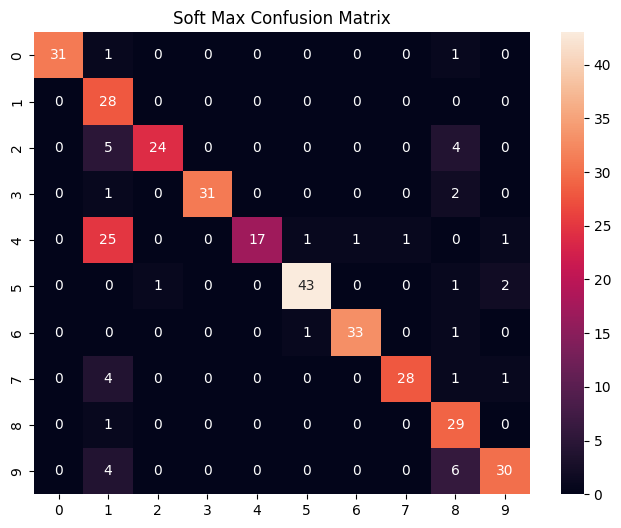

In [22]:
# Confusion Matrix

cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Soft Max Confusion Matrix")
plt.show()

## One vs Rest (OvR)

In [23]:
## Binary Logistic Regression

class MyLogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        
    def sigmoid(self, z):
        return 1/(1+np.exp(-z))
    
    def fit(self, X, y):
        n_sample, n_features=X.shape
        
        self.W=np.zeros(n_features)
        self.b=0
        
        for epoch in range(self.epochs):
            z=np.dot(X, self.W)+self.b
            y_pred=self.sigmoid(z)
            
            #gradients
            dw=(1/n_sample)*np.dot(X.T, (y_pred-y))
            db=(1/n_sample)* np.sum(y_pred-y)
            
            #update 
            self.W-=self.lr*dw
            self.b-=self.lr*db
            
    def predict_proba(self, X):
        z=np.dot(X, self.W)+self.b
        return self.sigmoid(z)
    
    def predict(self, X):
        return (self.predict_proba(X)>=0.5).astype(int)
            

In [24]:
# OvR Classifier
class MyOneRest:
    def __init__(self, lr=0.01, epochs=1000):    
        self.lr=lr
        self.epochs=epochs
        self.models=[]
        self.classes=None
        
    def fit(self, X, y):
        self.classes=np.unique(y)
        self.models=[]
        
        for c in self.classes:
            print(f"Training class {c} vs rest")
            
            y_binary=(y==c).astype(int)
            
            model=MyLogisticRegression(self.lr, self.epochs)
            model.fit(X, y_binary)
            
            self.models.append(model)
            
    def predict_proba(self, X):
        probs=[]
        
        for model in self.models:
            probs.append(model.predict_proba(X))
            
        return np.array(probs).T
    
    def predict(self, X):
        probs=self.predict_proba(X)
        return np.argmax(probs, axis=1)
    
    def score(self, X, y):
        preds=self.predict(X)
        return np.mean(preds==y)

## One vs One

In [25]:
from itertools import combinations

class MyOneVsOne:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        self.models=[]
        self.pairs=[]
        
    def fit(self, X, y):
        self.classes=np.unique(y)
        self.models=[]
        self.pairs=[]
        
        for (c1, c2) in combinations(self.classes , 2):
            print(f"Training {c1} vs {c2}")
            
            idx=(y==c1) | (y==c2)
            X_pair=X[idx]
            y_pair=y[idx]
            
            y_binary=(y_pair==c1).astype(int)
            
            model=MyLogisticRegression(self.lr, self.epochs)
            model.fit(X_pair, y_binary)
            
            self.models.append(model)
            self.pairs.append((c1, c2))
            
    def predict(self, X):
        votes=np.zeros((X.shape[0], len(self.classes)))
        
        for model, (c1, c2) in zip(self.models, self.pairs):
            preds=model.predict(X)
            
            for i in range(len(preds)):
                if preds[i]==1:
                    votes[i, c1]+=1
                else:
                    votes[i, c2]+=1
                    
        return np.argmax(votes, axis=1)
    
    def score(self, X, y):
        preds=self.predict(X)
        return np.mean(preds==y)
        

## Impelementation

In [26]:
#OvR
ovr=MyOneRest(lr=0.1, epochs=500)
ovr.fit(X_train_scaled, y_train)
y_pred_ovr=ovr.predict(X_test_scaled)

print("OvR Accuracy:", ovr.score(X_test_scaled, y_test))


#OvO
ovo=MyOneVsOne(lr=0.1, epochs=500)
ovo.fit(X_train_scaled, y_train)
y_pred_ovo=ovo.predict(X_test_scaled)

print("OvO Accuracy:", ovo.score(X_test_scaled, y_test))


Training class 0 vs rest
Training class 1 vs rest
Training class 2 vs rest
Training class 3 vs rest
Training class 4 vs rest
Training class 5 vs rest
Training class 6 vs rest
Training class 7 vs rest
Training class 8 vs rest
Training class 9 vs rest
OvR Accuracy: 0.9611111111111111
Training 0 vs 1
Training 0 vs 2
Training 0 vs 3
Training 0 vs 4
Training 0 vs 5
Training 0 vs 6
Training 0 vs 7
Training 0 vs 8
Training 0 vs 9
Training 1 vs 2
Training 1 vs 3
Training 1 vs 4
Training 1 vs 5
Training 1 vs 6
Training 1 vs 7
Training 1 vs 8
Training 1 vs 9
Training 2 vs 3
Training 2 vs 4
Training 2 vs 5
Training 2 vs 6
Training 2 vs 7
Training 2 vs 8
Training 2 vs 9
Training 3 vs 4
Training 3 vs 5
Training 3 vs 6
Training 3 vs 7
Training 3 vs 8
Training 3 vs 9
Training 4 vs 5
Training 4 vs 6
Training 4 vs 7
Training 4 vs 8
Training 4 vs 9
Training 5 vs 6
Training 5 vs 7
Training 5 vs 8
Training 5 vs 9
Training 6 vs 7
Training 6 vs 8
Training 6 vs 9
Training 7 vs 8
Training 7 vs 9
Training 8 vs

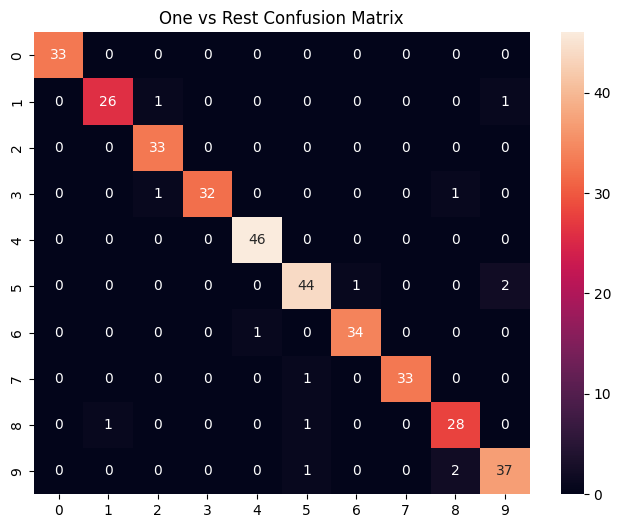

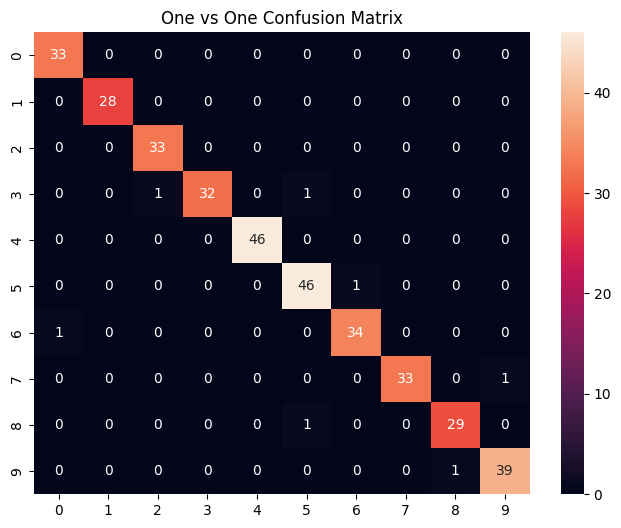

In [27]:
# Confusion MAtrix
cm_ovr=confusion_matrix(y_test, y_pred_ovr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_ovr, annot=True, fmt="d")
plt.title("One vs Rest Confusion Matrix")
plt.show()

cm_ovo=confusion_matrix(y_test, y_pred_ovo)

plt.figure(figsize=(8,6))
sns.heatmap(cm_ovo, annot=True, fmt="d")
plt.title("One vs One Confusion Matrix")
plt.show()

In [32]:
import numpy as np
values=np.array([10, 20, 30, 40, 50])
prob=np.array([0.3, 0.2, 0.1, 0.2, 0.2])

vals=np.random.choice(values, size=5, p=prob)

print(vals)


[10 10 30 10 10]
